<a href="https://colab.research.google.com/github/cafauzi13/Sentiment-Analysis-M-Paspor-PBA/blob/main/PBA_Analisis_Sentimen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Notebook Pelatihan Model Analisis Sentimen - Ulasan M-Paspor



## I. SETUP LINGKUNGAN DAN IMPOR LIBRARY


### 1.1. Instalasi Library yang Diperlukan

In [25]:
# 1. INSTALASI LIBRARY ]
!pip install pandas numpy scikit-learn tensorflow keras langdetect Sastrawi google-play-scraper nltk textblob

import pandas as pd
import numpy as np
import re
import string
import os
import time
import datetime
import requests
import joblib
import pickle
from pathlib import Path

# Library Scrapping
from google_play_scraper import Sort, reviews, app

# Library NLP & Preprocessing
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from langdetect import detect, DetectorFactory
from textblob import TextBlob

# Download data pendukung NLTK
nltk.download('punkt')
nltk.download('punkt_tab')

# Library Visualisasi (Dari Template Ibu)
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format='retina'
plt.style.use('seaborn-v0_8')
plt.rcParams["figure.figsize"] = (15,10)

# Library ML & Evaluasi (Dari Template Ibu)
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# Setup Reproduksibilitas
DetectorFactory.seed = 42

print("✅ Setup Library Gabungan Selesai. Siap Beraksi!")

✅ Setup Library Gabungan Selesai. Siap Beraksi!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### 1.2. Load Referensi

In [26]:
# --- 1. KAMUS ALAY (Normalisasi) ---
url_alay = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"
df_alay = pd.read_csv(url_alay)
alay_dict = dict(zip(df_alay['slang'], df_alay['formal']))

# --- 2. LEXICON INSET (Labeling) ---
# Kita ambil yang positif dan negatif
url_inset_pos = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
url_inset_neg = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

df_inset_pos = pd.read_csv(url_inset_pos, sep='\t')
df_inset_neg = pd.read_csv(url_inset_neg, sep='\t')
# Gabungkan jadi satu dictionary untuk cek skor kata
inset_dict = dict(zip(df_inset_pos['word'], df_inset_pos['weight']))
inset_dict.update(dict(zip(df_inset_neg['word'], df_inset_neg['weight'])))

# --- 3. COMBINED STOPWORDS (Pembersihan) ---
url_stopwords = "https://raw.githubusercontent.com/louisowen6/NLP_bahasa_resources/master/combined_stop_words.txt"
response = requests.get(url_stopwords)
# Simpan dalam bentuk set agar pencarian kata lebih cepat
combined_stopwords = set(response.text.splitlines())

print(f"✅ Kamus Alay: {len(alay_dict)} kata")
print(f"✅ InSet Lexicon: {len(inset_dict)} kata")
print(f"✅ Combined Stopwords: {len(combined_stopwords)} kata")

✅ Kamus Alay: 4331 kata
✅ InSet Lexicon: 9074 kata
✅ Combined Stopwords: 675 kata



## II. DATA ACQUISITION (SCRAPPING)



### 2.1. Scrapping ulasan M-Paspor dari Google Play

In [27]:
# II. DATA ACQUISITION (SCRAPPING M-PASPOR)

from google_play_scraper import Sort, reviews
import pandas as pd
import numpy as np

all_reviews = []
continuation_token = None
target_count = 18000

print(f"⏳ Memulai scrapping target {target_count} ulasan...")

while len(all_reviews) < target_count:
    result, continuation_token = reviews(
        'id.go.imigrasi.paspor_online',
        lang='id',
        country='id',
        sort=Sort.NEWEST,
        count=5000,
        continuation_token=continuation_token
    )
    all_reviews.extend(result)
    print(f"✅ Terambil: {len(all_reviews)} ulasan...")

    if not continuation_token:
        break

⏳ Memulai scrapping target 18000 ulasan...
✅ Terambil: 5000 ulasan...
✅ Terambil: 10000 ulasan...
✅ Terambil: 15000 ulasan...
✅ Terambil: 18150 ulasan...


In [28]:
# Mengubah hasil list menjadi DataFrame
df_mpaspor = pd.DataFrame(all_reviews)

# 2. Seleksi Kolom
# Kita ambil kolom: content, score, thumbsUpCount, reviewCreatedVersion, at, replyContent, repliedAt
df_mpaspor = df_mpaspor.loc[:, ["content", "score", "thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

# 3. Menampilkan Informasi Versi Aplikasi
print("\n--- Analisis Versi Aplikasi ---")
versions = df_mpaspor['reviewCreatedVersion'].unique()
print(f"Daftar Versi: {versions}")
print(f"Total Versi Unik: {len(versions)}")

# 4. Simpan ke CSV
df_mpaspor.to_csv('df_mpaspor_reviews.csv', index=False)

print(f"\n🔥 Total Akhir: {len(df_mpaspor)} ulasan berhasil didownload dan disimpan!")
df_mpaspor.head()


--- Analisis Versi Aplikasi ---
Daftar Versi: ['7.3.10' None '7.2.5' '7.2.3' '6.4.0' '6.9.0' '6.9.2' '6.1.0' '5.4.7'
 '7.3.7' '7.3.6' '6.9.1' '6.7.0' '7.2.0' '7.1.3' '6.2.4' '5.2.1' '6.6.3'
 '6.3.0' '6.6.2' '6.2.5' '6.2.3' '3.0.2' '6.0.2' '6.0.1' '5.0.3' '4.1.0'
 '4.2.0' '2.9.3']
Total Versi Unik: 29

🔥 Total Akhir: 18150 ulasan berhasil didownload dan disimpan!


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,Tolong diperbaiki. Kenapa ga bisa pilih tangga...,2,0,7.3.10,2026-03-09 05:08:17,None,NaT
1,aplikasi spam. Harusnya bkn aplikasi pendaftar...,1,0,7.3.10,2026-03-09 02:49:28,None,NaT
2,ada error: kode otp email saat pendaftaran tid...,1,0,7.3.10,2026-03-08 13:27:58,None,NaT
3,"Aplikasi Negara, yang bikin kita geleng geleng...",1,0,7.3.10,2026-03-07 08:46:23,None,NaT
4,bagus aplikasi ini,5,0,None,2026-03-06 07:34:04,None,NaT


### 2.2. Inisiasi Stemmer & Fungsi Preprocessing

In [29]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

print("Menyiapkan Stemmer Sastrawi...")
factory = StemmerFactory()
stemmer = factory.create_stemmer()
print("✅ Stemmer siap!")

Menyiapkan Stemmer Sastrawi...
✅ Stemmer siap!


In [30]:
def preprocess_v1(text):
    # BASIC CLEANING
    text = str(text).lower() # Case folding
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Hapus URL
    text = re.sub(r'[-+]?[0-9]+', '', text)           # Hapus angka
    text = re.sub(r'[^\w\s]', '', text)               # Hapus tanda baca

    # NORMALISASI ALAY
    words = text.split()
    normalized_words = [alay_dict.get(word, word) for word in words]
    text = " ".join(normalized_words)

    # STEMMING (Mencari akar kata - Sastrawi)
    text = stemmer.stem(text)

    # TOKENISASI
    tokens = word_tokenize(text)

    # STOPWORDS REMOVAL
    tokens = [word for word in tokens if word not in combined_stopwords and len(word) > 1]

    return tokens

### 2.3. Eksekusi ke DataFrame

In [31]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

# Coba dulu 100
print("⏳ Memulai Preprocessing & Tokenisasi (Sampel 100 data)...")

# kolom baru 'tokens'
df['tokens'] = df['text'].head(100).apply(preprocess_v1)

print("✅ Selesai!")
print(df[['text', 'tokens']].head(10))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


⏳ Memulai Preprocessing & Tokenisasi (Sampel 100 data)...
✅ Selesai!
                                                text  \
0  Tolong diperbaiki. Kenapa ga bisa pilih tangga...   
1  aplikasi spam. Harusnya bkn aplikasi pendaftar...   
2  ada error: kode otp email saat pendaftaran tid...   
3  Aplikasi Negara, yang bikin kita geleng geleng...   
4                                 bagus aplikasi ini   
5  min syaa Uda donlod knpa ga bisa ya? katanya p...   
6              daftar pon gak bisa kapan bisa daftar   
7  pada saat isi alamat pada bagian pilih provini...   
8  Di aplikasi ga ada FAQ. Perubahan cara bayar j...   
9  tanggal kedatangan gabisa di klik, proses terh...   

                                              tokens  
0                                   [pilih, tanggal]  
1  [aplikasi, spam, aplikasi, daftar, aplikasi, d...  
2           [error, kode, otp, email, daftar, masuk]  
3  [aplikasi, negara, bikin, geleng, geleng, kepa...  
4                                  [bag

### Initial Sentiment Analysis (TextBlob)

⏳ Menghitung polarity dan subjectivity
                                             content  score  \
0  Tolong diperbaiki. Kenapa ga bisa pilih tangga...      2   
1  aplikasi spam. Harusnya bkn aplikasi pendaftar...      1   
2  ada error: kode otp email saat pendaftaran tid...      1   
3  Aplikasi Negara, yang bikin kita geleng geleng...      1   
4                                 bagus aplikasi ini      5   

   sentiment_polarity  sentiment_subjective  
0                 0.0                   0.0  
1                 0.0                   0.0  
2                 0.0                   0.0  
3                 0.0                   0.0  
4                 0.0                   0.0  

📊 Menampilkan Distribusi Skor Rating (Histogram)...


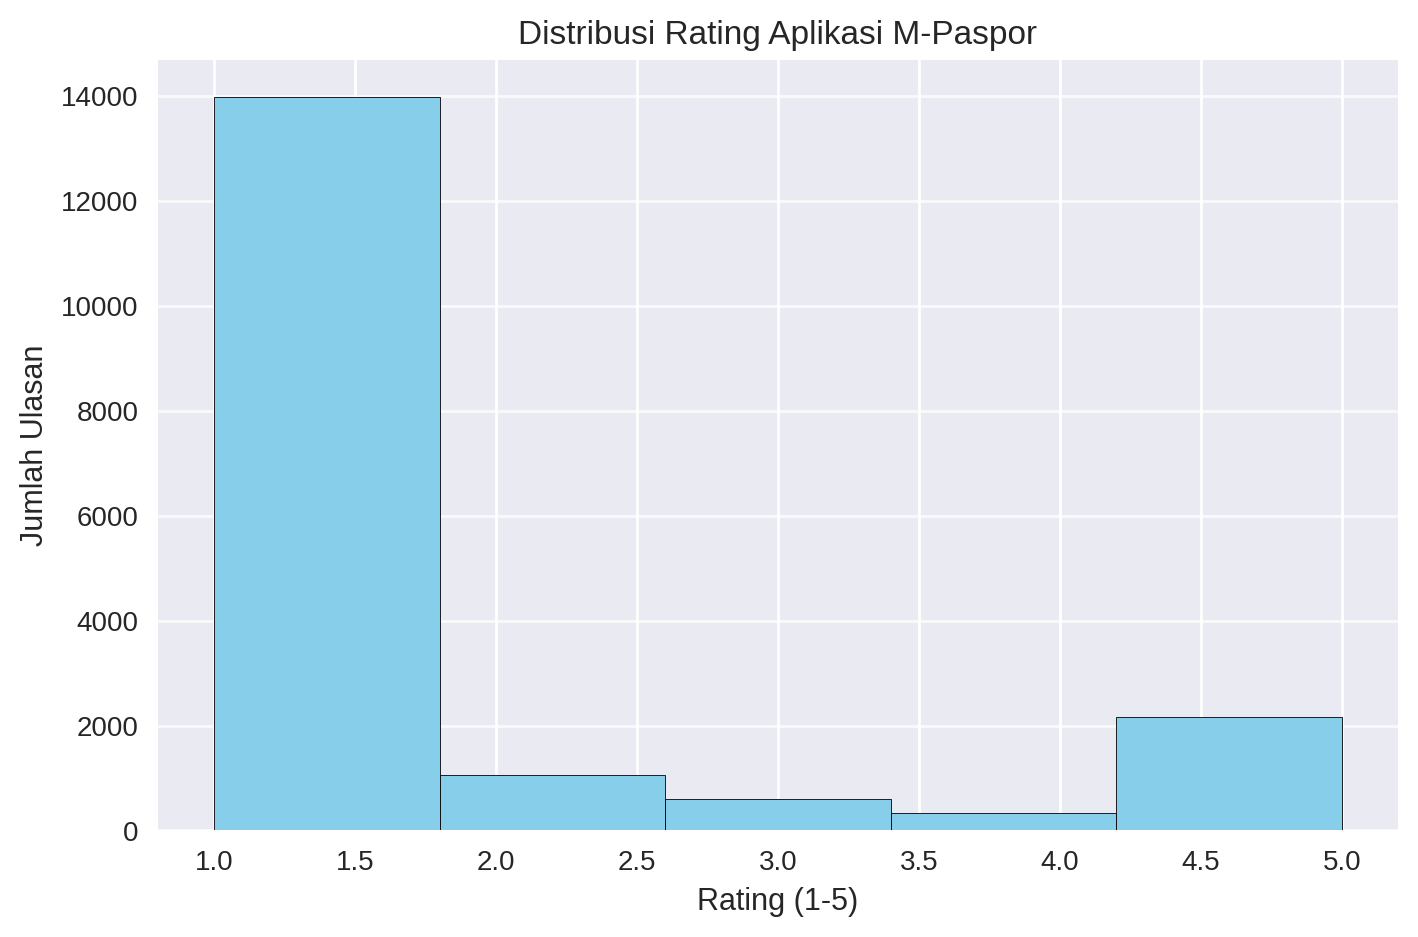


Jumlah ulasan per rating:
score
5     2170
4      332
3      607
2     1063
1    13978
Name: count, dtype: int64


In [32]:
from textblob import TextBlob
import matplotlib.pyplot as plt

print("⏳ Menghitung polarity dan subjectivity")

# Kita gunakan kolom 'content' sesuai DataFrame hasil scrap terbaru
df_mpaspor['sentiment_polarity'] = df_mpaspor['content'].apply(lambda x: TextBlob(str(x)).polarity)
df_mpaspor['sentiment_subjective'] = df_mpaspor['content'].apply(lambda x: TextBlob(str(x)).subjectivity)

# Menampilkan hasil skor awal
print(df_mpaspor.loc[:, ["content", "score", "sentiment_polarity", "sentiment_subjective"]].head())

# --- VISUALISASI DISTRIBUSI RATING ---
print("\n📊 Menampilkan Distribusi Skor Rating (Histogram)...")
plt.figure(figsize=(8, 5))
plt.hist(df_mpaspor['score'], bins=5, color='skyblue', edgecolor='black')
plt.title('Distribusi Rating Aplikasi M-Paspor')
plt.xlabel('Rating (1-5)')
plt.ylabel('Jumlah Ulasan')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Menghitung value counts (Sesuai template ibu)
print("\nJumlah ulasan per rating:")
print(df_mpaspor['score'].value_counts().sort_index(ascending=False))

In [33]:
df.to_csv('Tugas_1A_Mpaspor_Tokenized.csv', index=False)
print("✅ File tersimpan!")

✅ File tersimpan!


In [34]:
!pip freeze > requirements.txt

## III. PREPROCESSING TEKS

### 3.1.

## IV. PREPROCESSING TEKS BAHASA INDONESIA
### 4.1. Fungsi Pembersihan Teks Utama

## V. PERSIAPAN DATA UNTUK PELATIHAN MODEL
*Bagian ini dijalankan setelah Bagian IV selesai dan final_df sudah terbentuk*
### 5.1. Pemisahan Fitur dan Label

### 5.2. Encoding Label

### 5.3. Pembagian Data Pelatihan dan Pengujian
 *Kita perlu dua skema pembagian untuk 3 percobaan: 80/20 dan 70/30*

## VI. EKSTRAKSI FITUR
### 6.1. Tokenizer dan Padding untuk Deep Learning
*Mengubah teks menjadi urutan angka (indeks kata)*

### 6.2. TF-IDF untuk Machine Learning Klasik

## VII. IMPLEMENTASI TRAINING (3 skema)


## VIII. INFERENSI/PREDIKSI